In [1]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
     

X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)
     

df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})
     

df.shape
     

(100, 3)

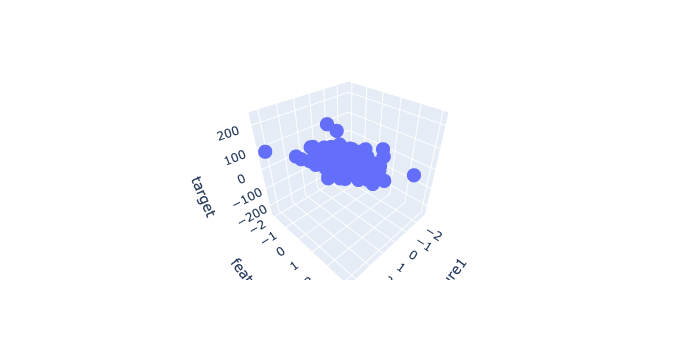

MAE 32.92388201004097
MSE 1547.2929494385621
R2 score 0.8065829636955271


In [3]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()
     

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)
     

from sklearn.linear_model import LinearRegression
     

lr = LinearRegression()
     

lr.fit(X_train,y_train)
     
LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,)

y_pred = lr.predict(X_test)
     

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

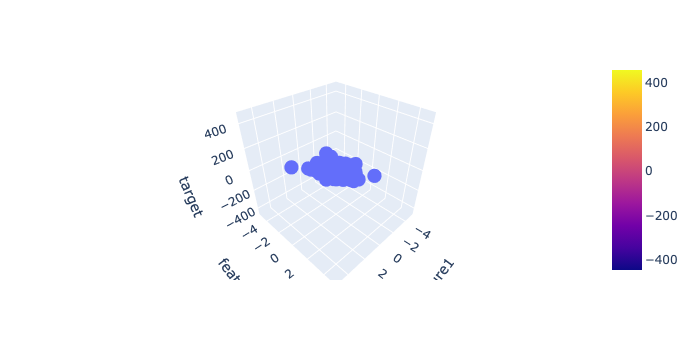

In [5]:

x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

z = z_final

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [6]:
lr.coef_

lr.intercept_
     

np.float64(5.245274616078351)